In [ ]:
# ============================================================
# Imports
# ============================================================
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# File Paths / Configuration
# ============================================================
GRID_SHP = r"/Users/ks/Desktop/Wu/LA_Tiffs/01_Processed_Output/02_Grid_Coverage/01_SOLA_Grid/SoLA_70m_grid.shp"

HIGHWAYS_GPKG = (
    r"/Users/ks/Desktop/Wu/Unfiltered_highways/"
    r"NTAD_National_Highway_Freight_Network_222556858296404895.gpkg"
)

OUTPUT_GRID_GPKG = (
    r"/Users/ks/Desktop/Wu/Unfiltered_highways/"
    r"SoLA_70m_grid_with_highway_flag.gpkg"
)

OUTPUT_DIR = os.path.dirname(OUTPUT_GRID_GPKG)

GRID_ID_FIELD = "GRID_ID"
FLAG_FIELD = "near_highway"


# ============================================================
# Functions
# ============================================================
def flag_highway_intersections(grid_gdf, highways_path, out_field = FLAG_FIELD):
    """
    Flag each grid cell if it intersects a highway.
    """

    highways_gdf = gpd.read_file(highways_path)

    if highways_gdf.crs != grid_gdf.crs:
        highways_gdf = highways_gdf.to_crs(grid_gdf.crs)

    grid_work = grid_gdf.reset_index(drop = True).copy()
    grid_work["_grid_row_id"] = grid_work.index

    joined = gpd.sjoin(
        grid_work[["_grid_row_id", "geometry"]],
        highways_gdf[["geometry"]],
        how = "left",
        predicate = "intersects",
    )

    intersecting_ids = set(
        joined.loc[
            joined["index_right"].notna(),
            "_grid_row_id"
        ]
    )

    grid_gdf = grid_gdf.copy()
    grid_gdf[out_field] = (
        grid_gdf.index
        .to_series()
        .reset_index(drop = True)
        .isin(intersecting_ids)
        .values
    )

    n_flagged = int(grid_gdf[out_field].sum())

    print(
        f"{n_flagged}/{len(grid_gdf)} grid cell(s) intersect a highway "
        f"({100 * n_flagged / len(grid_gdf):.1f}%)."
    )

    return grid_gdf, highways_gdf

# ============================================================
# Main
# ============================================================
if not os.path.isfile(GRID_SHP):
    raise FileNotFoundError(
        f"Grid file not found:\n{GRID_SHP}"
    )

if not os.path.isfile(HIGHWAYS_GPKG):
    raise FileNotFoundError(
        f"Highways file not found:\n{HIGHWAYS_GPKG}"
    )

os.makedirs(OUTPUT_DIR, exist_ok = True)

grid_gdf = gpd.read_file(GRID_SHP)

print(
    f"Loaded grid: {len(grid_gdf)} cells "
    f"(CRS={grid_gdf.crs})"
)

grid_gdf, highways_gdf = flag_highway_intersections(
    grid_gdf,
    HIGHWAYS_GPKG,
)

grid_gdf.to_file(
    OUTPUT_GRID_GPKG,
    driver = "GPKG",
)

print(f"Saved -> {OUTPUT_GRID_GPKG}")

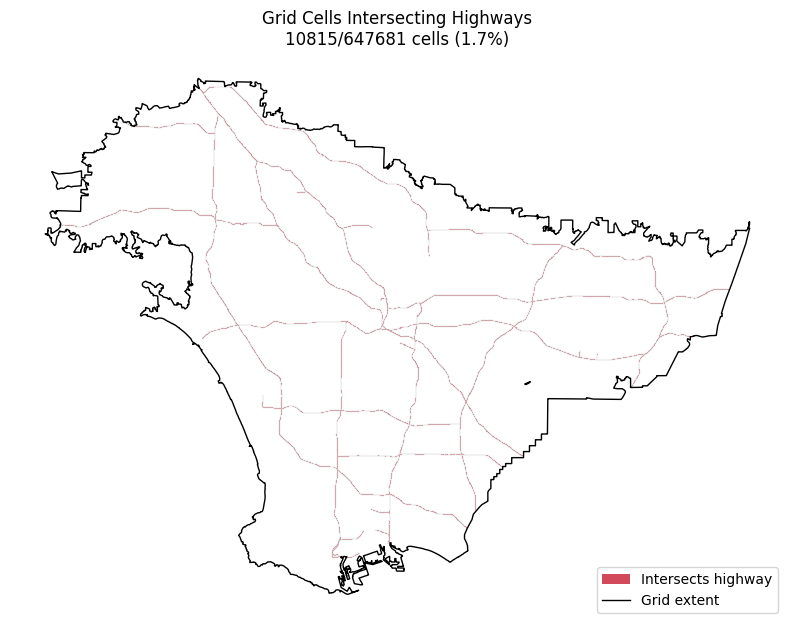

Saved -> /Users/ks/Desktop/Wu/Unfiltered_highways/grid_highway_intersection.png


,GRID_ID,geometry,near_highway
0,1,"POLYGON ((382381.587 3730088.988, 382311.587 3...",False
1,2,"POLYGON ((382451.587 3730088.988, 382381.587 3...",False
2,3,"POLYGON ((382521.587 3730088.988, 382451.587 3...",False
3,4,"POLYGON ((382591.587 3730088.988, 382521.587 3...",False
4,5,"POLYGON ((382661.587 3730088.988, 382591.587 3...",False
...,...,...,...
647676,647677,"POLYGON ((362361.587 3800018.988, 362291.587 3...",False
647677,647678,"POLYGON ((362361.587 3800018.988, 362361.587 3...",False
647678,647679,"POLYGON ((362221.587 3800088.988, 362220.326 3...",False
647679,647680,"POLYGON ((362291.587 3800088.988, 362221.587 3...",False


In [7]:
def plot_highway_flagged_grid(
        grid_gdf,
        highways_gdf,
        output_dir,
        flag_field = FLAG_FIELD,
):
    """
    Plot the highway intersection results: only the flagged (highway-
    intersecting) grid cells are shown, on top of the overall grid/study
    region outline for spatial context. Highway lines themselves are not drawn.
    """

    fig, ax = plt.subplots(figsize = (10, 10))

    # Overall grid extent outline (dissolved boundary of every cell, not just flagged ones)
    grid_outline = grid_gdf.geometry.union_all()
    gpd.GeoSeries([grid_outline], crs = grid_gdf.crs).boundary.plot(
        ax = ax,
        color = "black",
        linewidth = 1,
    )

    # Only the highway-intersecting cells
    grid_gdf[grid_gdf[flag_field]].plot(
        ax = ax,
        color = "#d1495b",
        edgecolor = "lightgray",
        linewidth = 0.2,
    )

    n_flagged = int(grid_gdf[flag_field].sum())
    n_total = len(grid_gdf)

    ax.set_title(
        f"Grid Cells Intersecting Highways\n"
        f"{n_flagged}/{n_total} cells "
        f"({100 * n_flagged / n_total:.1f}%)"
    )

    ax.axis("off")

    legend = [
        Patch(facecolor = "#d1495b", label = "Intersects highway"),
        Line2D(
            [0], [0],
            color = "black",
            linewidth = 1,
            label = "Grid extent",
        ),
    ]

    ax.legend(handles = legend, loc = "lower right")

    out_path = os.path.join(
        output_dir,
        "grid_highway_intersection.png",
    )

    fig.savefig(
        out_path,
        dpi = 150,
        bbox_inches = "tight",
    )

    plt.show()

    print(f"Saved -> {out_path}")

    return out_path


plot_highway_flagged_grid(
    grid_gdf,
    highways_gdf,
    OUTPUT_DIR,
)

grid_gdf